## Data Wrangling II

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("academic_performance.csv")
df.head()

,id,math,science,english,attendance,study_hours
0,1,81.0,41.0,31,61.0,4
1,2,44.0,67.0,47,73.0,2
2,3,90.0,57.0,99,78.0,5
3,4,50.0,53.0,46,92.0,5
4,5,53.0,53.0,46,74.0,3


## Scan for Missing Values

In [24]:
df.isnull().sum()

id              0
math           20
science        20
english         0
attendance     20
study_hours     0
dtype: int64

In [25]:
df.describe()

,id,math,science,english,attendance,study_hours
count,1000.000000,980.000000,980.000000,1000.000000,980.000000,1000.000000
mean,500.500000,64.340816,65.909184,61.883000,74.779592,3.616000
std,288.819436,21.776424,18.658342,21.764168,14.633360,1.696296
min,1.000000,30.000000,35.000000,25.000000,50.000000,1.000000
25%,250.750000,46.000000,49.000000,43.000000,62.000000,2.000000
50%,500.500000,64.000000,66.000000,61.000000,75.000000,4.000000
75%,750.250000,82.000000,81.000000,80.000000,88.000000,5.000000
max,1000.000000,300.000000,99.000000,220.000000,99.000000,6.000000


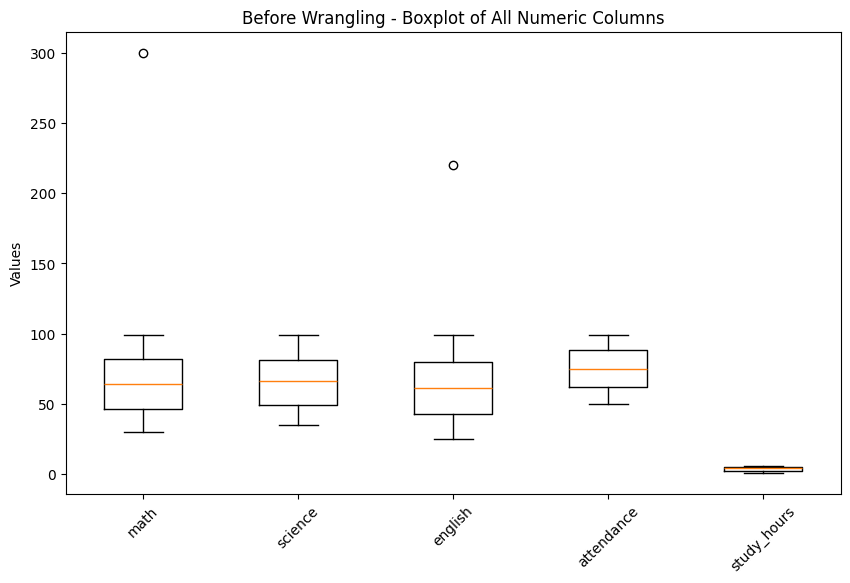

In [26]:
numeric_cols = ['math','science','english','attendance','study_hours']

plt.figure(figsize=(10,6))
plt.boxplot([df[col].dropna() for col in numeric_cols],
            tick_labels=numeric_cols)
plt.title("Before Wrangling - Boxplot of All Numeric Columns")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

## Handle Missing Values

In [27]:
df['math'] = df['math'].fillna(df['math'].median())
df['science'] = df['science'].fillna(df['science'].median())
df['attendance'] = df['attendance'].fillna(df['attendance'].mean())

In [28]:
df.isnull().sum()

id             0
math           0
science        0
english        0
attendance     0
study_hours    0
dtype: int64

## Scan Numeric Variables for Outliers

In [29]:
def treat_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return col.clip(lower, upper)

In [31]:
df['math'] = treat_outliers(df['math'])
df['science'] = treat_outliers(df['science'])
df['english'] = treat_outliers(df['english'])
df['attendance'] = treat_outliers(df['attendance'])

## Data Transformation

In [32]:
df['math_log'] = np.log(df['math'] + 1)
df[['math', 'math_log']].head()

,math,math_log
0,81.0,4.406719
1,44.0,3.806662
2,90.0,4.510860
3,50.0,3.931826
4,53.0,3.988984


In [33]:
df.head()
df.describe()

,id,math,science,english,attendance,study_hours,math_log
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,64.168875,65.911000,61.798500,74.779592,3.616000,4.123303
std,288.819436,20.348976,18.470632,21.308935,14.486140,1.696296,0.337241
min,1.000000,30.000000,35.000000,25.000000,50.000000,1.000000,3.433987
25%,250.750000,46.750000,50.000000,43.000000,62.750000,2.000000,3.865938
50%,500.500000,64.000000,66.000000,61.000000,75.000000,4.000000,4.174387
75%,750.250000,82.000000,81.000000,80.000000,87.000000,5.000000,4.418841
max,1000.000000,134.875000,99.000000,135.500000,99.000000,6.000000,4.911735


## Outlier Detection Using Boxplot

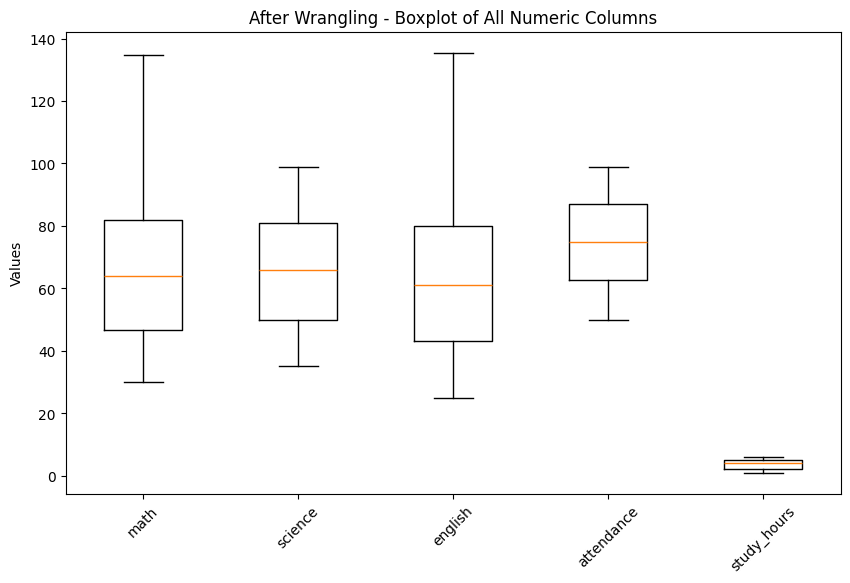

In [34]:
numeric_cols = ['math','science','english','attendance','study_hours']

plt.figure(figsize=(10,6))
plt.boxplot([df[col].dropna() for col in numeric_cols],
            tick_labels=numeric_cols)
plt.title("After Wrangling - Boxplot of All Numeric Columns")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [36]:
df.head()

,id,math,science,english,attendance,study_hours,math_log
0,1,81.0,41.0,31.0,61.0,4,4.406719
1,2,44.0,67.0,47.0,73.0,2,3.806662
2,3,90.0,57.0,99.0,78.0,5,4.510860
3,4,50.0,53.0,46.0,92.0,5,3.931826
4,5,53.0,53.0,46.0,74.0,3,3.988984


In [37]:
df.describe()

,id,math,science,english,attendance,study_hours,math_log
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,64.168875,65.911000,61.798500,74.779592,3.616000,4.123303
std,288.819436,20.348976,18.470632,21.308935,14.486140,1.696296,0.337241
min,1.000000,30.000000,35.000000,25.000000,50.000000,1.000000,3.433987
25%,250.750000,46.750000,50.000000,43.000000,62.750000,2.000000,3.865938
50%,500.500000,64.000000,66.000000,61.000000,75.000000,4.000000,4.174387
75%,750.250000,82.000000,81.000000,80.000000,87.000000,5.000000,4.418841
max,1000.000000,134.875000,99.000000,135.500000,99.000000,6.000000,4.911735
